<a href="https://colab.research.google.com/github/batireeduienkh6-source/2026_tues_bigdatacomputing_class/blob/main/7%EC%A3%BC%EC%B0%A8_%EB%8D%B0%EC%9D%B4%ED%84%B0%EB%B6%84%EC%84%9D%ED%8C%8C%EC%9D%B4%ED%94%84%EB%9D%BC%EC%9D%B8_%EC%A0%95%EB%A6%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ [7주차 실습] 날씨 데이터 분석 파이프라인 및 엑셀 저장 완성하기
- 데이터 생성 → 전처리 → 분석 → 시각화 -> 파일로 저장
- numpy를 이용해 가상의 시계열 날씨 데이터를 생성
- 시계열 데이터 분석 관련 주요 함수
  - **df.to_excel()**:
    - 여러 개의 분석 결과를 하나의 엑셀 파일(.xlsx) 안에 시트별로 나누어 저장
    - **pd.ExcelWriter()** 를 사용
  - **df.to_csv(encoding='utf-8-sig')** :
    - 전처리가 끝난 "깨끗한" 내부 데이터를 다시 csv 파일로 저장
  - **pd.read_csv(encoding='cp949')** :
    -  외부에서 데이터를 가져오는 것()     
  - **zip()** :
    - 여러 개의 리스트(또는 반복 가능한 객체)를 같은 순서 인덱스끼리 짝을 지어 묶어주는 내장 함수
    - 보통 여러 데이터를 동시에 for문으로 처리할 때 가장 많이 사용     
  - **pd.to_datetime()** :
    - 문자열 "2023-01-01"을 '연/월/일/시/분/초' 날짜 객체 타입으로 변경
    - **df.set_index()** :
      - 데이터프레임의 일반 컬럼을 '인덱스'로 설정
    - 이 두 과정(날짜 데이터변환-> 날짜 기준 인덱스 설정)을 통해 판다스가 날짜를 이해하는 시계열 데이터가 완성    
  - **df[컬럼].interpolate()** :
    - 결측치가 발생했을 때, 앞의 데이터와 뒤의 데이터를 선으로 이어서 그 선 위에 있는 값을 결측치로 논리적으로 채우는 방식
    - 기온, 주가, 센서 데이터처럼 앞뒤 값이 연속성을 가질 때 사용.
    - fillna()로 특정 숫자를 채울 때보다 데이터의 추세를 훨씬 잘 보존
  - **df.rolling()**:
    - '움직이는 창'을 설정해 그 안의 값들을 계산하는 슬라이딩 윈도우 기능
    - 데이터의 급격한 변동을 줄이고 전체적인 추세를 파악.    
  - **Min-Max Scaling**:
    - 서로 다른 범위를 가진 수치 데이터를 0과 1 사이의 일정한 범위로 변환
    - 최소값은 0, 최대값은 1이 되도록 선형적으로 변환.
  - **df.map()** :
    - 시리즈나 인덱스의 각 요소를 하나씩 꺼내어 특정 규칙(함수 또는 딕셔너리)에 통과시킨 뒤, 그 결과값으로 치환하는 기능.   
  - **df.index.month**:
    - 시계열 인덱스에서 'Month' 정보만 뽑아내는 기능.
  - **sns.histplot()**:
    - 데이터가 특정 구간에 얼마나 많이 쌓여 있는지(빈도)를 보여줌
    - **kde=True** 옵션을 넣으면 부드러운 곡선을 그려주어 전체적인 분포의 형태를 쉽게 파악.
  - **sns.heatmap()**:
    - 수치로 가득 찬 표를 색상으로 변환

In [26]:
# 데이터 프레임 결합
import pandas as pd
import numpy as np

# 1. 시계열 데이터프레임 준비 : A지점에서 1월 1일부터 3일간 수집한 기온
df_a = pd.DataFrame({
'date': pd.to_datetime( ['2023-01-01', '2023-01-02', '2023-01-03']),
'temp': [10, 12, 13]
})
print("\n df_a:", df_a)

# 2. 시계열 데이터프레임 준비 : B지점에서 1월 2일부터 4일간 수집한 기온 (날짜가 A와 일부 겹침)
df_b = pd.DataFrame({
'date': pd.to_datetime( ['2023-01-02', '2023-01-03', '2023-01-04']),
'temp': [15, 16, 14]
})
print("\n df_b:", df_b)

#3.
df = pd.concat([df_a, df_b], axis = 0, join= "outer")
print("\n", df)
#4
df_merge = df_a.merge(df_b, on = "date", how = "outer")
print("\n", df_merge)
#5
df_summary = df.pivot_table(index= 'date', columns = 'temp')


 df_a:         date  temp
0 2023-01-01    10
1 2023-01-02    12
2 2023-01-03    13

 df_b:         date  temp
0 2023-01-02    15
1 2023-01-03    16
2 2023-01-04    14

         date  temp
0 2023-01-01    10
1 2023-01-02    12
2 2023-01-03    13
0 2023-01-02    15
1 2023-01-03    16
2 2023-01-04    14

         date  temp_x  temp_y
0 2023-01-01    10.0     NaN
1 2023-01-02    12.0    15.0
2 2023-01-03    13.0    16.0
3 2023-01-04     NaN    14.0


In [4]:
#df.to_csv() & pd.read_csv(), df.toexcel()
import pandas as pd

#1 . 데이터 생성
data = { '도시' : ['서울', '부산', '대구', '인천', '광주'],
            '평균기온' : [15.2, 18.5, 20.1, 16.5, 19.3]}
df = pd.DataFrame(data)
print("\n", df)

#2.df-> csv파일 저장 (to_csv())
df.to_csv("sample_data.csv" , index = False, encoding = "utf-8-sig")
#3. csv -> df 형태로 다시 읽어 오기 (readMcsv())
loaded_df = pd.read_csv("sample_data.csv", encoding = "utf-8-sig")
print("\n", loaded_df)

#4. 엑셀 파일로 저장하기 (df.to_excel())
with pd.ExcelWriter("final_report.xlsx") as f:
  #각 테이블을 서로 다른 시트 이름으로 저장
  loaded_df.to_excel(f, sheet_name = "날씨 데이터")
  df.to_excel(f, sheet_name = "데이터분석 결과" , index = False)
  loaded_df.to_excel(f, sheet_name = " 데이터분석 결과", index = False)
#


    도시  평균기온
0  서울  15.2
1  부산  18.5
2  대구  20.1
3  인천  16.5
4  광주  19.3

    도시  평균기온
0  서울  15.2
1  부산  18.5
2  대구  20.1
3  인천  16.5
4  광주  19.3


In [6]:
# zip()
names = ['서울', '부산', '제주']
temps = [15.5, 18.2, 20.1]
#zip으로 몪기 -> 리스트의 동일 인덱스에 있는  겄거리 몪어서 하나의 튜플로 반환
zipped = zip(names, temps)
print(list(zipped))

#용도
for name, temp in zipped:
  print(f"({name},{temp})")

[('서울', 15.5), ('부산', 18.2), ('제주', 20.1)]


In [10]:
#pd.to_datetime(), df.set_index()
import pandas as pd
# 1 . 시계열 데이터 생성
df = pd.DataFrame({'date' : ['2025-01-01' , '2025-01-02', '2025-01-03'],
                   'temp' : [10, 11, 12]})
print("\n", df)
print("\n", df['date'].dtype) # pandas 자료형 : object
#2. object => datetime64( 날짜객체타입)
pd.to_datetime(df["date"])
print("\n", df)
print("\n", df['date'].dtype)
# 3.#data_time를 데이터프로그램의 새 인덱스로 설정 (set_index())
df.set_index('date_time', inplace = True)
print("\n", df)
#4 .월 정보를 추출
print(df.index.day)


          date  temp
0  2025-01-01    10
1  2025-01-02    11
2  2025-01-03    12

 object

 object


In [ ]:
#df. interpolate() : 결측치를 선형적으로 보관하기
#fillna() =>
import pandas as pd
import numpy as np

#1. 시계열 데이터 준비
data = {'temp' :[10.0, 12.0, np.nan, np.nan, 16.0, 18.0]}
df = pd.DataFrame(data)
print( "\n", df)

#2 결측치 전처리!!!!
df['temp_fill_mean'] = df['temp'].mean()
print("\n",df)



         temp
0  28.820262
1  22.000786
2  24.893690
3  31.204466
4  29.337790


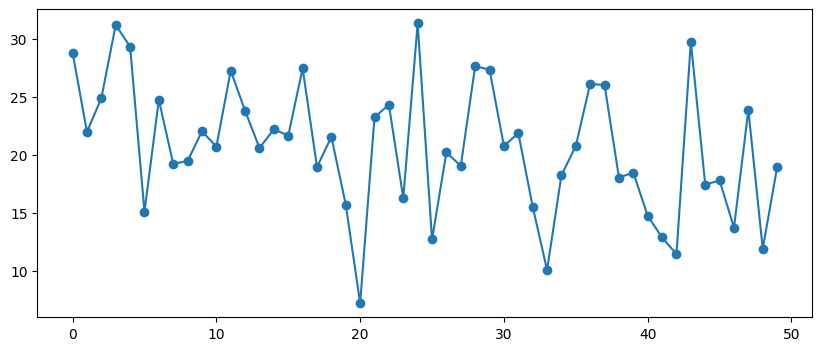

In [12]:
#df.rolling(wndow=)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#1. 50일 간의 기on을 생성
np.random.seed(0)
df = pd.DataFrame( {'temp' : np.random.normal (20,5, 50)} )
print("\n", df.head())

# 7일치 기온 데이터을 묶어서 / 기온의 평균을 구하여 열로 추가
df['7day_avg_temp'] = df['temp'].rolling(window = 7 ).mean()
# 시각화
plt.figure(figsize= (10,4))
plt.plot(df['temp'],label = "Daily temp", marker = 'o')

In [14]:
#MIn-Max scaling : 데이터 전처리 작업에서 필요
import pandas as pd
import numpy as np

#1
data = {
    'temp': [ -10, 0.15, 25, 35, np.nan], # -10 -35
    'rainfall' : [ 0, 50, 100, 200, 300] # 0 ~ 300

}
df = pd.DataFrame(data)
print("\n", df)
#2
def min_max_scale(series):
  result =(series - series.min()) / (series.max() - series.min())
  return result

  df['temp_scaled'] = min_max_scale(df['temp'])
  df['rainfall_scaled'] = min_max_scale(df['rainfall'])

  print("\n", df)


     temp  rainfall
0 -10.00         0
1   0.15        50
2  25.00       100
3  35.00       200
4    NaN       300


In [16]:
# se.map()
import pandas as pd
#샘플 점수 성적 데이터
df = pd.DataFrame({'score': [45, 56, 88, 79, 95] })

#60 점 미만이면 "fail", 아니면 "pass"
def check_score(se):
  if se < 60:
    return "fail"
  else:
    return "pass"

#map 적용
df['result'] = df['score'].map(check_score)
print(df)

   score result
0     45   fail
1     56   fail
2     88   pass
3     79   pass
4     95   pass



                  temp  day
2026-03-01  20.878814    6
2026-03-02  17.519866    0
2026-03-03  24.341255    1
2026-03-04  19.659853    2
2026-03-05  16.357826    3
2026-03-06  19.095898    4
2026-03-07  10.287898    5
2026-03-08  14.523622    6
2026-03-09  19.902603    0
2026-03-10  14.351164    1
2026-03-11  19.270231    2
2026-03-12  16.431531    3
2026-03-13  12.032111    4
2026-03-14  14.474235    5
2026-03-15  18.549474    6
2026-03-16  18.863091    0
2026-03-17  18.614879    1
2026-03-18  19.798012    2
2026-03-19  19.781549    3
2026-03-20  16.471277    4
2026-03-21  23.448199    5
2026-03-22  15.513428    6
2026-03-23  16.537974    0
2026-03-24  23.378850    1
2026-03-25  22.092910    2
2026-03-26  20.558329    3
2026-03-27  11.503403    4
2026-03-28  23.792239    5
2026-03-29  20.713619    6
2026-03-30  24.982705    0


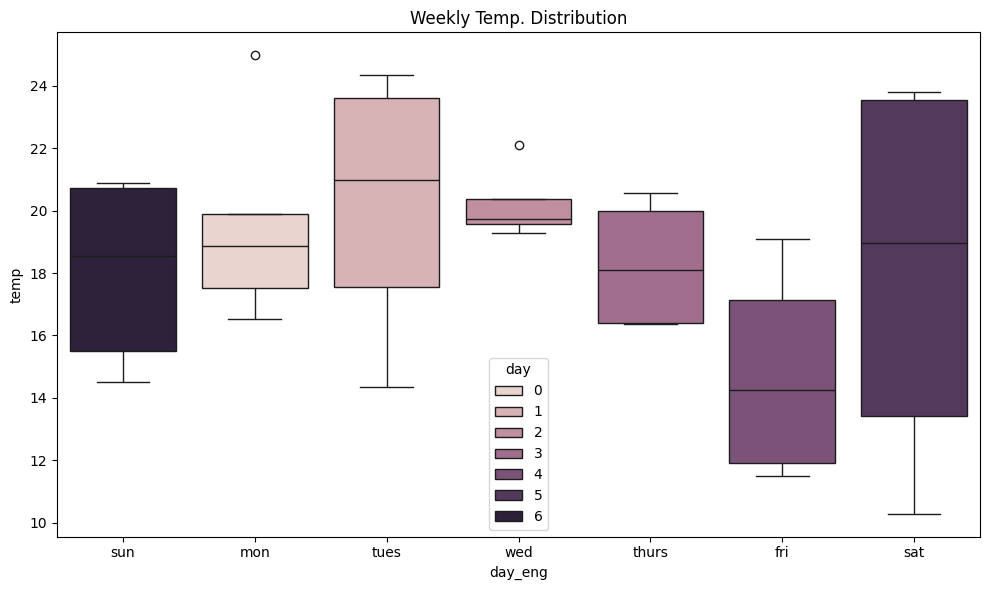


 day_eng
fri      14.775672
mon      19.561248
sat      18.000643
sun      18.035792
thurs    18.282309
tues     20.171537
wed      20.205252
Name: temp, dtype: float64


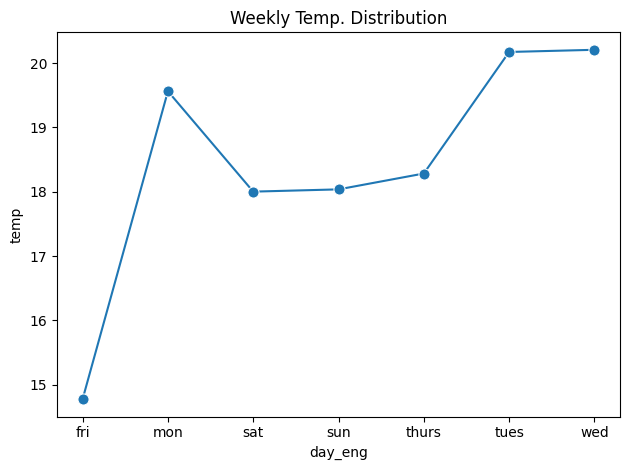

In [22]:
#pd.data_range(), df.index.dayofweek, se, reindex()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#1
dates = pd.date_range(start="2026-03-01", periods = 30)
df = pd.DataFrame({
    "temp" : np.random.uniform(10,25,30)}, index = dates)
df['day'] = df.index.dayofweek
print("\n", df)
#2
day_names = {0:'mon', 1:'tues', 2:'wed', 3:'thurs', 4:'fri', 5:'sat', 6: 'sun'}
df['day_eng'] = df.index.dayofweek.map(day_names)
# 3. 요일별 / 기온 분포 그래프 시각화 (sns.boxplot())
plt.figure(figsize=(10, 6))
sns.boxplot(data = df, x= 'day_eng', y= 'temp', hue = "day")
plt.title("Weekly Temp. Distribution")
plt.tight_layout()
plt.show()
# 4. 요일별/ 평균 기온 집계을 이용하여 시각화 (sns.lineplot())

#(1) 요일별 기온 평균 집계
weekly_temp_mean = df.groupby('day_eng')['temp'].mean()
print("\n", weekly_temp_mean)
sns.lineplot(weekly_temp_mean, marker='o', markersize = 8)
plt.title("Weekly Temp. Distribution")
plt.tight_layout()
plt.show()